# 06 - Deep Learning Models

## Objective

The objective of this notebook is to develop and evaluate Deep Learning models for UAV network intrusion detection using the preprocessed network communication dataset.

Unlike the previous notebook, which focused on traditional Machine Learning algorithms, this notebook investigates whether Deep Learning can better learn complex patterns present in UAV network traffic.

The workflow of this notebook includes:

- Loading the preprocessed training and testing datasets.
- Converting the data into PyTorch tensors.
- Creating DataLoaders for efficient batch processing.
- Building a baseline Multi-Layer Perceptron (MLP) model.
- Training and evaluating the MLP model.
- Developing an LSTM-based intrusion detection model.
- Comparing Deep Learning models with the best-performing Machine Learning baseline.
- Identifying the most suitable model for UAV intrusion detection.

The results obtained from this notebook will help determine whether Deep Learning provides a significant improvement over traditional Machine Learning approaches for cyberattack detection in UAV communication networks.

In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

In [4]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (26481, 32)
Testing Features  : (6621, 32)
Training Labels   : (26481, 1)
Testing Labels    : (6621, 1)


## Converting Data into PyTorch Tensors

PyTorch models require the input data to be represented as tensors. Therefore, the processed NumPy arrays are converted into floating-point feature tensors and integer label tensors.

In [5]:
X_train_tensor = torch.tensor(
    X_train.values,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test.values,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values.flatten(),
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test.values.flatten(),
    dtype=torch.long
)

In [6]:
print("Training Feature Tensor :", X_train_tensor.shape)
print("Testing Feature Tensor  :", X_test_tensor.shape)

print("Training Label Tensor   :", y_train_tensor.shape)
print("Testing Label Tensor    :", y_test_tensor.shape)

Training Feature Tensor : torch.Size([26481, 32])
Testing Feature Tensor  : torch.Size([6621, 32])
Training Label Tensor   : torch.Size([26481])
Testing Label Tensor    : torch.Size([6621])


### Observation

The datasets have been successfully converted into PyTorch tensors. These tensors can now be efficiently processed by neural network models during training and evaluation.

## Creating DataLoaders

To improve training efficiency, the tensors are organized into DataLoaders. DataLoaders divide the dataset into mini-batches and enable efficient shuffling during training.

In [7]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [8]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [9]:
print("Training Batches :", len(train_loader))
print("Testing Batches  :", len(test_loader))

Training Batches : 414
Testing Batches  : 104


### Observation

The training and testing datasets have been successfully prepared as DataLoaders. These DataLoaders will be used to efficiently train and evaluate the Deep Learning models in the following sections.

## Baseline Deep Learning Model: Multi-Layer Perceptron (MLP)

As the first Deep Learning baseline, a Multi-Layer Perceptron (MLP) is developed.

The MLP is a fully connected feedforward neural network that learns complex non-linear relationships between the input features and the target classes. It provides a suitable baseline for evaluating whether Deep Learning offers any improvement over traditional Machine Learning models.

The architecture consists of:

- An input layer matching the number of network traffic features.
- Two hidden layers with ReLU activation.
- An output layer corresponding to the three intrusion classes.

In [10]:
class MLP(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)

        )

    def forward(self, x):
        return self.network(x)

In [11]:
input_size = X_train.shape[1]

num_classes = len(np.unique(y_train))

model = MLP(input_size, num_classes)

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)


## Defining the Loss Function and Optimizer

To train the neural network, a suitable loss function and optimization algorithm are required.

- CrossEntropyLoss is used for multi-class classification problems.
- Adam optimizer is selected because it provides efficient and stable convergence during training.

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## Training the MLP Model

The model is trained over multiple epochs using mini-batch gradient descent.

For each epoch:

- The model performs a forward pass.
- The loss is computed.
- Gradients are calculated using backpropagation.
- Model parameters are updated using the Adam optimizer.

In [13]:
epochs = 20

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for features, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(features)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/20] Loss: 0.7097
Epoch [2/20] Loss: 0.6455
Epoch [3/20] Loss: 0.6311
Epoch [4/20] Loss: 0.6262
Epoch [5/20] Loss: 0.6203
Epoch [6/20] Loss: 0.6167
Epoch [7/20] Loss: 0.6141
Epoch [8/20] Loss: 0.6103
Epoch [9/20] Loss: 0.6080
Epoch [10/20] Loss: 0.6052
Epoch [11/20] Loss: 0.6039
Epoch [12/20] Loss: 0.6013
Epoch [13/20] Loss: 0.5991
Epoch [14/20] Loss: 0.5978
Epoch [15/20] Loss: 0.5960
Epoch [16/20] Loss: 0.5954
Epoch [17/20] Loss: 0.5940
Epoch [18/20] Loss: 0.5941
Epoch [19/20] Loss: 0.5908
Epoch [20/20] Loss: 0.5894


## Training Loss Curve

The training loss is plotted to observe how the model learns over different epochs.

A decreasing loss indicates that the model is successfully minimizing the classification error during training.

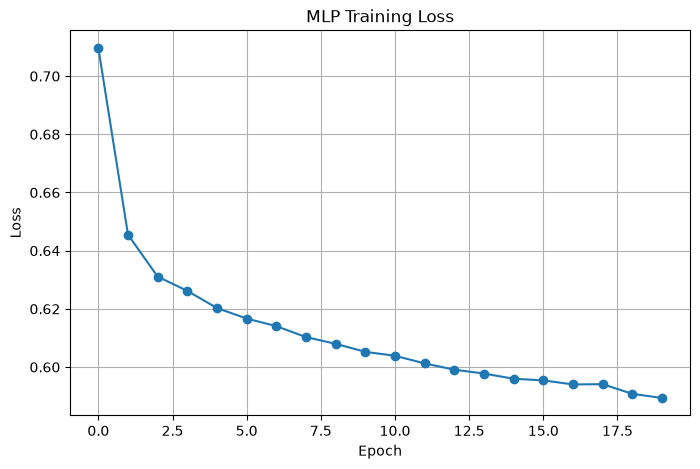

In [14]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o')

plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

## Model Evaluation

After training, the MLP model is evaluated on the test dataset.

The evaluation includes:
- Predicting the attack class for each test sample.
- Calculating the overall accuracy.
- Generating a classification report.
- Visualizing the confusion matrix.

In [15]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

In [16]:
accuracy = accuracy_score(y_true, y_pred)

print(f"MLP Accuracy : {accuracy:.4f}")

MLP Accuracy : 0.6688


In [17]:
print("Classification Report\n")

print(classification_report(y_true, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.62      0.64      0.63      2334
           1       0.61      0.49      0.54      2402
           2       0.76      0.94      0.84      1885

    accuracy                           0.67      6621
   macro avg       0.67      0.69      0.67      6621
weighted avg       0.66      0.67      0.66      6621



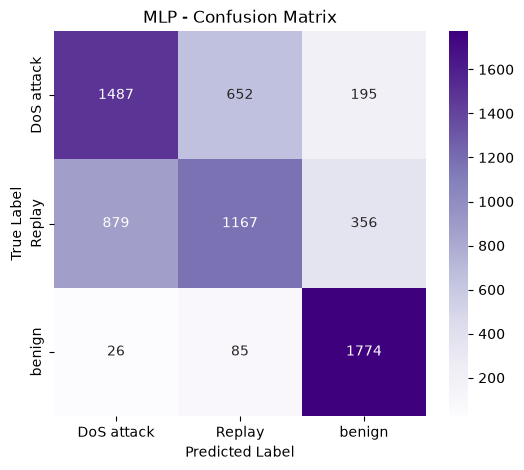

In [19]:
# Confusion Matrix

class_names = ["DoS attack", "Replay", "benign"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("MLP - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The baseline MLP achieved moderate performance (66.88% accuracy), outperforming Logistic Regression but remaining below tree-based ensemble methods such as Random Forest and XGBoost. This suggests that a simple feed-forward neural network may not fully capture the complex temporal and sequential characteristics present in UAV communication data. Therefore, an LSTM-based architecture is explored in the next phase.

## LSTM-Based Intrusion Detection Model

Unlike the MLP, which treats every feature independently, the LSTM (Long Short-Term Memory) network is designed to learn sequential patterns in the data.

Although each UAV network sample represents a single packet, the feature vector can be treated as a short sequence of network attributes. This allows the LSTM to learn dependencies between features that may improve intrusion detection performance.

The workflow includes:
- Reshaping the input data for LSTM.
- Creating PyTorch DataLoaders.
- Building the LSTM architecture.
- Training the model.
- Evaluating its performance.
- Comparing it with the baseline ML and MLP models.

In [20]:
# Reshape data for LSTM

X_train_lstm = X_train_tensor.view(-1, X_train_tensor.shape[1], 1)
X_test_lstm = X_test_tensor.view(-1, X_test_tensor.shape[1], 1)

print("Training Shape :", X_train_lstm.shape)
print("Testing Shape  :", X_test_lstm.shape)

Training Shape : torch.Size([26481, 32, 1])
Testing Shape  : torch.Size([6621, 32, 1])


The original feature vector is reshaped into a sequence format so that the LSTM can process the network attributes sequentially. Each feature is treated as one time step with a single input value.

In [21]:
# Create TensorDataset for LSTM

train_dataset_lstm = TensorDataset(
    X_train_lstm,
    y_train_tensor
)

test_dataset_lstm = TensorDataset(
    X_test_lstm,
    y_test_tensor
)

In [22]:
batch_size = 64

train_loader_lstm = DataLoader(
    train_dataset_lstm,
    batch_size=batch_size,
    shuffle=True
)

test_loader_lstm = DataLoader(
    test_dataset_lstm,
    batch_size=batch_size,
    shuffle=False
)

In [23]:
print("Training Batches :", len(train_loader_lstm))
print("Testing Batches  :", len(test_loader_lstm))

Training Batches : 414
Testing Batches  : 104


## LSTM Model Architecture

An LSTM (Long Short-Term Memory) network is used to learn sequential dependencies between the network features.

Model Architecture:
- 2-layer LSTM
- Hidden size = 128
- Dropout for regularization
- Fully Connected layer
- ReLU activation
- Output layer for 3 attack classes

Compared to the baseline MLP, the LSTM is expected to better capture relationships among network attributes.

In [24]:
class LSTMModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, num_classes):

        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        out, (hidden, cell) = self.lstm(x)

        out = hidden[-1]

        out = self.classifier(out)

        return out

In [25]:
#Create the model
input_size = 1
hidden_size = 128
num_layers = 2
num_classes = len(np.unique(y_train))

lstm_model = LSTMModel(
    input_size,
    hidden_size,
    num_layers,
    num_classes
)

print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)


## Training Configuration

The LSTM model is trained using the Cross Entropy Loss function for multi-class classification.

The AdamW optimizer is used for efficient weight updates, along with a learning rate scheduler to gradually reduce the learning rate during training.

The best model is saved based on the lowest training loss.

In [26]:
#loss fncn and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    lstm_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [27]:
#learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [28]:
num_epochs = 30

train_losses = []

best_loss = float("inf")

## Training the LSTM Model

The model is trained for multiple epochs using the training dataset.

During each epoch:
- Forward propagation is performed.
- The loss is computed.
- Gradients are backpropagated.
- Model parameters are updated.
- The learning rate scheduler monitors the training loss.
- The best-performing model is saved.

In [30]:
for epoch in range(num_epochs):

    lstm_model.train()

    running_loss = 0.0

    for inputs, labels in train_loader_lstm:

        optimizer.zero_grad()

        outputs = lstm_model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_lstm)

    train_losses.append(epoch_loss)

    scheduler.step(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(lstm_model.state_dict(), "../models/best_lstm_model.pth")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/30] | Loss: 0.7441
Epoch [2/30] | Loss: 0.7043
Epoch [3/30] | Loss: 0.6884
Epoch [4/30] | Loss: 0.6701
Epoch [5/30] | Loss: 0.6732
Epoch [6/30] | Loss: 0.6531
Epoch [7/30] | Loss: 0.6481
Epoch [8/30] | Loss: 0.6435
Epoch [9/30] | Loss: 0.6440
Epoch [10/30] | Loss: 0.6351
Epoch [11/30] | Loss: 0.6237
Epoch [12/30] | Loss: 0.6276
Epoch [13/30] | Loss: 0.6238
Epoch [14/30] | Loss: 0.6203
Epoch [15/30] | Loss: 0.6177
Epoch [16/30] | Loss: 0.6114
Epoch [17/30] | Loss: 0.6139
Epoch [18/30] | Loss: 0.6097
Epoch [19/30] | Loss: 0.6042
Epoch [20/30] | Loss: 0.6083
Epoch [21/30] | Loss: 0.6036
Epoch [22/30] | Loss: 0.5989
Epoch [23/30] | Loss: 0.6002
Epoch [24/30] | Loss: 0.5951
Epoch [25/30] | Loss: 0.5970
Epoch [26/30] | Loss: 0.5944
Epoch [27/30] | Loss: 0.5928
Epoch [28/30] | Loss: 0.5908
Epoch [29/30] | Loss: 0.5954
Epoch [30/30] | Loss: 0.5862


In [31]:
lstm_model.load_state_dict(torch.load("../models/best_lstm_model.pth"))

print("Best model loaded successfully!")

Best model loaded successfully!


In [32]:
#Evaluate on Test Set
# Evaluate LSTM Model

lstm_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_lstm:

        outputs = lstm_model(X_batch)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(predicted.numpy())

In [33]:
accuracy = accuracy_score(y_true, y_pred)

print(f"LSTM Accuracy : {accuracy:.4f}")

LSTM Accuracy : 0.6781


In [35]:
print("Classification Report\n")

print(classification_report(y_true, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.59      0.91      0.71      2334
           1       0.91      0.23      0.37      2402
           2       0.76      0.96      0.85      1885

    accuracy                           0.68      6621
   macro avg       0.75      0.70      0.64      6621
weighted avg       0.75      0.68      0.63      6621



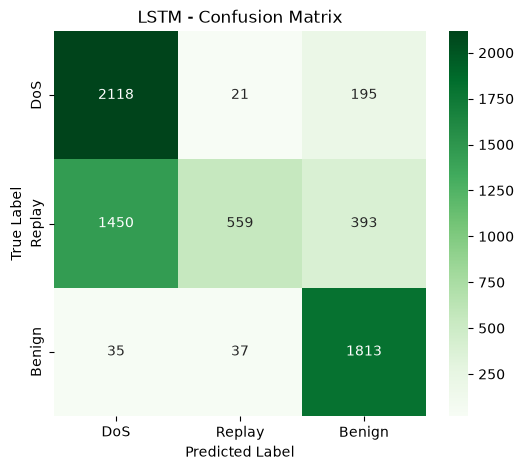

In [34]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["DoS", "Replay", "Benign"],
    yticklabels=["DoS", "Replay", "Benign"]
)

plt.title("LSTM - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

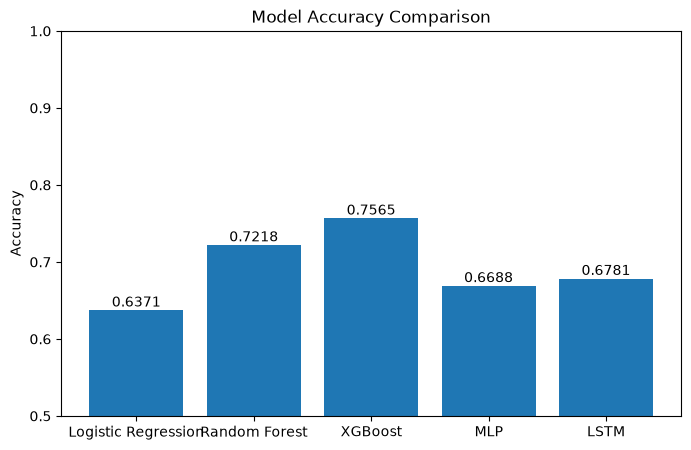

In [36]:
model_names = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "MLP",
    "LSTM"
]

accuracies = [
    0.6371,
    0.7218,
    0.7565,
    0.6688,
    accuracy
]

plt.figure(figsize=(8,5))

bars = plt.bar(model_names, accuracies)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.4f}",
        ha="center"
    )

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.5, 1.0)

plt.show()